#   HW1 - Introduction to Image Processing Course



### 1. Environment Setup and Preparations

Import libraries

In [77]:
import sys
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.image import imread, imsave
import pandas as pd
import numpy as np
import tensorflow as tf
import skimage as ski
from skimage.io import imread
from PIL import Image

Libraries versions

In [78]:
print('pandas version: '+ pd.__version__)
print('numpy version: '+np.__version__)
print('tensorflow version: '+tf.__version__)
print('scikit-image version: '+ski.__version__)

pandas version: 2.2.2
numpy version: 1.26.4
tensorflow version: 2.17.0
scikit-image version: 0.24.0


In [79]:
conda_env = os.environ.get('CONDA_DEFAULT_ENV')
print(f"current Conda environment: '{conda_env}'.")

current Conda environment: 'image_processing_env'.


`image_common_utils` functions

In [72]:
# Description: It displays many images in many rows and column
# cmap='gray'; row_plot = 1; img= [img, camera]
def show_image(img, cmap='gray', row_plot = 1):
    if not isinstance(img, list):
        img = [img]

    if len(img) == 1:
        plt.imshow(img[0], cmap=cmap) # cm.gray
    else:
        # Get column count
        col_plot = len(img) // row_plot
        fig, axes = plt.subplots(row_plot, col_plot)
        for count in range(len(img)): # count= 1
            axes[count].imshow(img[count], cmap=cmap)
    plt.show()
    return
# end of show_image


`import_image` function to import all relevant images

In [59]:
def import_image (path):
    img = imread(path)
    img.shape  # H x W x C
    img.size  # multiplication of HxWxC
    type(img)
    img.dtype
    return(img)

Import all images from `image_data` folder

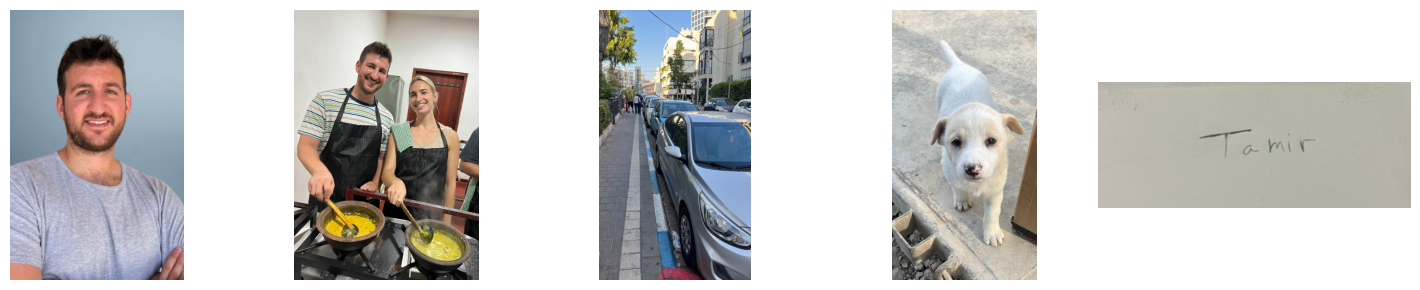

In [111]:
selfie = import_image('./images_data/selfie.jpg')
friends = import_image('./images_data/friends.jpg')
street = import_image('./images_data/street.jpg')
animal = import_image('./images_data/animal.jpg')
words = import_image('./images_data/words.jpg')

show_image([selfie, friends, street, animal, words], None)


### 2. Image Formats and Color Schemes

Import the wanted image

In [122]:
selfie = import_image('./images_data/selfie.jpg')

Loop function to iterate all the different color schemes and file formats

In [123]:
def change_color_scheme(image, base_name):
    # Define the color schemes and file formats
    color_schemes = {
        "RGB": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        "GRAYSCALE": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
        "HSL": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2HLS),
        "CYMK": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2RGB),  # PIL handles CMYK later
    }
    file_formats = [".tiff", ".jpeg", ".png", ".gif"]

    for scheme_name, conversion in color_schemes.items():
        try:
            # Convert the image
            converted_image = conversion(image)

            # Special handling for CMYK
            cmyk_image = None
            if scheme_name == "CYMK":
                converted_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                cmyk_image = converted_image.convert("CMYK")

            for file_format in file_formats:
                try:
                    output_image_name = f"{base_name}_{scheme_name}{file_format}"

                    if scheme_name == "CYMK" and cmyk_image:
                        if file_format == ".gif":
                            cmyk_image.convert("RGB").save(output_image_name, format="GIF")
                        else:
                            cmyk_image.save(output_image_name)
                    else:
                        if len(converted_image.shape) == 2 and file_format != ".gif":  # Grayscale image
                            converted_image_to_save = cv2.cvtColor(converted_image, cv2.COLOR_GRAY2BGR)
                        else:
                            converted_image_to_save = converted_image

                        if file_format == ".gif":
                            Image.fromarray(cv2.cvtColor(converted_image_to_save, cv2.COLOR_BGR2RGB)).save(output_image_name, format="GIF")
                        else:
                            cv2.imwrite(output_image_name, converted_image_to_save)

                    print(f"Saved: {output_image_name}")
                except Exception as e:
                    print(f"Could not save {scheme_name} in {file_format}: {e}")
        except Exception as e:
            print(f"Could not convert to {scheme_name}: {e}")
    return


csv file format

Results

In [124]:
change_color_scheme(selfie,"selfie")

Saved: selfie_RGB.tiff
Saved: selfie_RGB.jpeg
Saved: selfie_RGB.png
Saved: selfie_RGB.gif
Saved: selfie_GRAYSCALE.tiff
Saved: selfie_GRAYSCALE.jpeg
Saved: selfie_GRAYSCALE.png
Saved: selfie_GRAYSCALE.gif
Saved: selfie_HSL.tiff
Saved: selfie_HSL.jpeg
Saved: selfie_HSL.png
Saved: selfie_HSL.gif
Saved: selfie_CYMK.tiff
Saved: selfie_CYMK.jpeg
Could not save CYMK in .png: cannot write mode CMYK as PNG
Saved: selfie_CYMK.gif


### 3. Upscaling and Downscaling

### 4. Shape Drawing

### 5. Video Annotation

### 6. Image Histogram Analysis